# Lab 2: Hardware–Software Model Co-Design

### Introduction

In **Lab 1**, you saw that compressing transformer weights down to **2 bits** reduced model size by ×16 with only a modest accuracy drop. But compression alone is a *software-centric* solution; actual deployment only succeeds when the model cooperates with the underlying silicon.

In this lab, you’ll adopt a **hardware–software co-design** perspective, treating quantization as the critical interface between the network and its deployment hardware. Quantization affects both **model accuracy** and **execution efficiency**, making it the ideal lever for co-design.

Specifically, you will:

- **Wrap every `nn.Linear` in a quantized integer-only `QLinear` module**  
- **Post-quantize both weights and activations layerwise**, selecting precision from **8 → 2 bits** for each individual layer 
- **Measure performance of each quantization configuration** using **Cross Entropy** and **memory consumption**  
- **Perform automated layerwise bit-width search** to optimize a hardware-aware objective function

> **Why co-design matters:**  
> A model that looks efficient in software may still bottleneck on real hardware due to memory access patterns, compute throughput, or unsupported bit-widths. Hardware–software co-design ensures the model structure aligns with hardware constraints, enabling deployment that is both **accurate** and **efficient** on edge devices.

---

### Lab Objectives

1. **Implement `QLinear`**, a simulated integer GEMM layer with scale-offset dequantization, compatible with PyTorch CPU kernels  
2. **Post-quantize a pretrained model checkpoint** using per-layer {8, 4, 2}-bit precision, and export metadata for downstream hardware cost modeling  
3. **Profile** model size and **Validation Cross Entropy**  
4. **Run a non-linear optimization algorithm** to identify a per-layer quantization configuration that minimizes a joint objective (accuracy vs. efficiency)

---

By the end, you'll produce a deployment-ready language model with a **per-layer optimal quantization configuration**, striking the best trade-off between hardware efficiency and model fidelity.



In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from functools import partial
from typing import Dict, Any, Tuple

import pytorch_lightning as pl
from hyperopt import fmin, tpe, rand, hp, Trials, space_eval, STATUS_OK

from src.lab1.shakespeare_trainer import ShakespeareModule

/home/oliver/miniconda3/envs/advanced-ai-on-arm/lib/python3.13/site-packages/torch/__init__.py:1624: UserWarning: This API is going to be deprecated, please see https://pytorch.org/docs/main/notes/cuda.html#tensorfloat-32-tf32-on-ampere-and-later-devices (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:78.)
  _C._set_float32_matmul_precision(precision)


## 1. Building `QLinear`

The first step is to implement a quantized linear layer that supports configurable bit-widths. This will allow us to experiment with different per-layer quantization strategies and conduct a hardware–software co-design process to identify an optimal configuration for deployment.

We’ll define a `QLinear` layer that performs **symmetric uniform quantization**, mapping floating-point tensors to signed integers in the range  
$ - (2^{b-1} - 1), \dots, + (2^{b-1} - 1) $, using a single scale factor **s**.

### Forward Pass Overview:

1. **Quantize** input activations to signed integers.  
2. Perform **GEMM** (general matrix multiplication) using pre-quantized weights.  
3. **Dequantize** the accumulator by multiplying it with the product of the input and weight scale factors.  
4. Add the (floating-point) bias term if used.

>  This implementation prioritizes clarity over performance.



In [2]:
class QLinear(nn.Module):
    """
    A fully-connected layer with symmetric uniform quantization for weights and activations.
    """
    def __init__(
        self,
        in_features: int,
        out_features: int,
        bias: bool = True,
        weight_bitwidth: int = 8,
        act_bitwidth: int = 8,
    ) -> None:
        super().__init__()
        self.in_features = in_features
        self.out_features = out_features
        self.weight_bitwidth = weight_bitwidth
        self.act_bitwidth = act_bitwidth

        # Buffers to hold quantized weight and quantization scale
        self.register_buffer(
            "qweight",
            torch.zeros(out_features, in_features, dtype=torch.float32),
        )
        self.register_buffer("weight_scale", torch.ones(1))

        # Optional bias
        if bias:
            self.register_buffer("bias", torch.zeros(out_features, dtype=torch.float32))
        else:
            self.bias = None

    @staticmethod
    def _quantize_tensor(
        x: torch.Tensor, bitwidth: int
    ) -> Tuple[torch.Tensor, torch.Tensor]:
        """
        Quantize a tensor to signed integers in range [-2^(b-1), 2^(b-1)-1].
        Returns (quantized_tensor, scale).
        """
        qmax = 2 ** (bitwidth - 1) - 1
        rmax = x.abs().max() 
        scale = rmax / qmax if rmax > 0 else torch.tensor(1.0, device=x.device)
        q = torch.clamp(torch.round(x / scale), -qmax, qmax)
        return q, scale

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # 1. Quantize activations
        qx, act_scale = self._quantize_tensor(x, self.act_bitwidth)

        # 2. Integer GEMM
        qx = qx.to(self.qweight.dtype)
        acc = qx.matmul(self.qweight.t())

        # 3. Dequantize
        y = acc * act_scale * self.weight_scale

        # 4. Add bias if present
        if self.bias is not None:
            y = y + self.bias

        return y

    def __repr__(self) -> str:
        # Name of the layer
        return (
            f"{self.__class__.__name__}("
            f"in={self.in_features}, out={self.out_features}, "
            f"w_bits={self.weight_bitwidth}, a_bits={self.act_bitwidth})"
        )

### Quick Sanity Check

Run the cell below to quantize a random matrix at 2, 4, and 8-bit precision,  
and print the reconstruction error.  
> As bit-width increases, the reconstruction error should decrease. Let's run the cell below just to check that. 


In [3]:
# %% 
torch.manual_seed(0)
sample = torch.randn(1000)
for b in (2, 4, 8):
    q, s = QLinear._quantize_tensor(sample, b)
    err = (sample - q * s).abs().mean().item()
    print(f"{b}-bit | mean-abs-error: {err:.6f}")


2-bit | mean-abs-error: 0.761839
4-bit | mean-abs-error: 0.144003
8-bit | mean-abs-error: 0.008115


## 2. Swapping Layers In-Place

To enable **per-layer mixed-precision quantization**, where each layer can be quantized with an arbitrary bit-width, we define a function that traverses the model and replaces each `nn.Linear` layer with a quantized equivalent.

The key mechanism relies on a dictionary called **`qconfig`** which maps the fully qualified names of `nn.Linear` modules to their desired bit-widths. This configuration is then used to locate and swap the corresponding layers in-place with quantized versions (`QLinear`) that store the quantized weights.

The functions below implement this mechanism:
- `quantize_linear`: replaces a single `nn.Linear` with a quantized version given a particular weight bit-width.
- `quantize_model`: applies `quantize_linear` to each layer in the model, quantizing with the per-layer precision specified in `qconfig`.
- `default_qconfig`: generates a default `qconfig` dictionary in which every layer has 8-bit precision.

The `qconfig` dictionary looks like this:

```text
{
  "model.transformer_blocks.0.attn.q_proj": 4,
  "model.transformer_blocks.0.attn.k_proj": 2,
  ...
}

In [4]:
def quantize_linear(layer: nn.Linear, weight_bitwidth=8, act_bitwidth=8):
    qlayer = QLinear(layer.in_features, layer.out_features,
                     bias=layer.bias is not None,
                     weight_bitwidth=weight_bitwidth,
                     act_bitwidth=act_bitwidth)
    q_w, w_s = QLinear._quantize_tensor(layer.weight.data, weight_bitwidth)
    qlayer.qweight.copy_(q_w)
    qlayer.weight_scale.copy_(w_s)
    if layer.bias is not None:
        qlayer.bias.copy_(layer.bias.data)
    return qlayer


def quantize_model(root: nn.Module, qconfig: Dict[str, int]):
    for path, bw in qconfig.items():
        parent_path, _, attr = path.rpartition('.')
        parent = root if not parent_path else root.get_submodule(parent_path)
        setattr(parent, attr,
                quantize_linear(getattr(parent, attr),
                                weight_bitwidth=bw, act_bitwidth=bw))
    return root


def default_qconfig(model: ShakespeareModule, bitwidth=8):
    cfg = {}
    for name, mod in model.model.transformer_blocks.named_modules():
        if isinstance(mod, nn.Linear):
            cfg[f"model.transformer_blocks.{name}"] = bitwidth
    return cfg


### Per-Layer Quantization Error in Transformer Blocks

When applying the `qconfig` to quantize each `nn.Linear` layer, we can assess how sensitive different layers are to quantization. The plot below visualizes this sensitivity by computing the **relative mean squared error (MSE)** between full-precision weights and their quantized versions:

$
\text{Relative MSE} = \frac{\mathbb{E}[(W - \hat{W})^2]}{\mathbb{E}[W^2]}
$

Each bar represents a `nn.Linear` layer in the transformer blocks, quantized to a fixed bit-width (e.g., 4-bit). 

- **Blue bars** indicate self-attention projection layers.  
- **Orange bars** represent feedforward layers.

This metric helps identify which layers are more prone to quantization error. For example, **feedforward down-projection** and **Attention output** layers often show elevated error, suggesting they may require higher precision to maintain model accuracy and later layers, often are more robust to quantization than earlier ones.

>  **Note**: This analysis only considers **weight quantization error**, not the end-to-end effect on downstream performance (e.g., next-token prediction). Nonetheless, it serves as a useful proxy for guiding **mixed-precision strategies**.




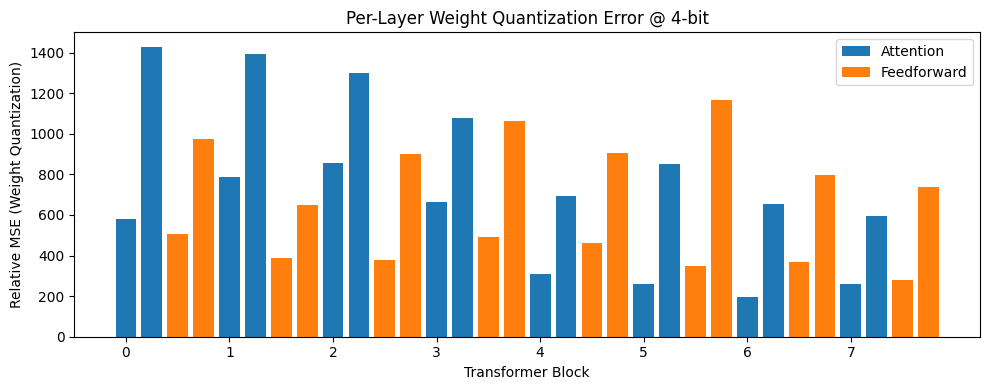

In [5]:
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from matplotlib.patches import Patch

def plot_weight_quantization_error(model: ShakespeareModule, bitwidth=8):
    errors = []
    block_ids = []
    colors = []

    for name, mod in model.model.transformer_blocks.named_modules():
        if isinstance(mod, nn.Linear):
            # Quantize weights
            q_w, _ = QLinear._quantize_tensor(mod.weight.data, bitwidth)

            # Compute relative MSE
            mse = torch.mean((mod.weight.data - q_w) ** 2)
            norm = torch.mean(mod.weight.data ** 2)
            rel_error = mse / norm

            # Parse block id and classify layer type
            if '.' in name:
                block_id, layer_type = name.split('.', 1)
                block_ids.append(int(block_id))
                if 'attn' in layer_type.lower():
                    colors.append('tab:blue')   # attention layer
                else:
                    colors.append('tab:orange') # feedforward
                errors.append(rel_error.item())

    # Determine one tick position per block
    unique_blocks = list(dict.fromkeys(block_ids))
    ticks = [block_ids.index(b) for b in unique_blocks]

    # Plot
    plt.figure(figsize=(10, 4))
    plt.bar(range(len(errors)), errors, color=colors)
    plt.xticks(ticks=ticks, labels=unique_blocks, rotation=0)
    plt.xlabel("Transformer Block")
    plt.ylabel("Relative MSE (Weight Quantization)")
    plt.title(f"Per-Layer Weight Quantization Error @ {bitwidth}-bit")
    plt.tight_layout()

    # Custom legend
    legend_elements = [
        Patch(facecolor='tab:blue', label='Attention'),
        Patch(facecolor='tab:orange', label='Feedforward'),
    ]
    plt.legend(handles=legend_elements, loc='upper right')
    plt.show()


# Example usage
model = ShakespeareModule.load_from_checkpoint(
    'src/lab1/checkpoints/pretrained/float-best-large.ckpt',
    batch_size=6
)
plot_weight_quantization_error(model, bitwidth=4)

## 3. Accuracy Metric: Validation Loss on a Single Batch

As we transition to **software-hardware co-design**, our goal is to explore the space of per-layer bitwidth configurations under a joint cost function that balances **memory footprint** and **task accuracy**.

To evaluate the **accuracy impact** to the cost function of a given quantization configuration, we measure the model's **cross-entropy loss** on a single held-out validation batch. This provides a fast and task-relevant proxy for accuracy degradation due to quantization, enabling efficient evaluation during search.

Given model outputs $\mathbf{z} \in \mathbb{R}^{B \times V}$—where $B$ is the batch size and $V$ is the vocabulary size—and ground-truth labels $y \in \{0, \ldots, V{-}1\}^B$, the validation loss is computed as:

$
\mathcal{L}_{\text{val}} = -\frac{1}{B} \sum_{i=1}^B \log \left( \frac{e^{z_{i, y_i}}}{\sum_{j=1}^V e^{z_{i, j}}} \right)
$

This is the standard **cross-entropy loss**, measuring the divergence between predicted softmax probabilities and the true class labels for each input.

In PyTorch, this is implemented as:

```python
F.cross_entropy(logits, y)
```

>  **Note**:  
> This metric captures the **end-to-end functional effect** of quantization on the model’s output, reflecting how quantization impacts actual task performance.  
> In contrast to weight-level metrics (like relative MSE), which assess error in isolation, this loss provides a **task-specific measure of accuracy degradation**, making it more suitable for optimization in a software-hardware co-design loop.



In [6]:
def compute_validation_loss(model, loss_fn, dataloader, device):
    model.eval()
    
    with torch.no_grad():
        x, y = next(iter(dataloader))
        x, y = x.to(device), y.to(device)
        logits = model.model(x)
        logits = logits.view(-1, logits.size(-1))  # shape: [6*128, 1024]
        y = y.view(-1) 
        loss = loss_fn(logits, y)
        
    return loss.item()

## 4. Memory Metric: Static Model Size

In our software-hardware co-design cost function, we also need to quantify the **hardware cost** of any given quantization configuration.  
To do this, we compute the model’s **static memory footprint** in **bytes**, which reflects the total size of the model's parameters after quantization.

This metric provides a direct estimate of how much memory the model will occupy on disk or RAM, and depends on the per-layer bit-widths specified in the `qconfig`.

###  What gets counted?

- **Quantized weights** (e.g., `QLinear.qweight`) are stored using the **bit-width defined in `qconfig`**
- **Biases, embeddings, and normalization layers** are kept in **full precision**: 32 bits per parameter
- **Other unquantized parameters** (e.g., LayerNorm scales or modules not explicitly quantized) are also assumed to be **32-bit floats**

For a quantized linear layer with weight shape $[m, n]$ and bit-width $b$, the contribution to memory is:

$
\text{Size}_{\text{qweight}} = m \times n \times b \text{ bits}
$

Full-precision components (e.g., biases) contribute:

$
\text{Size}_{\text{fp32}} = k \times 32 \text{ bits}
$

Finally, we convert from bits to **bytes** by dividing the total by 8.

>  **Note**:  
> This metric captures the **static parameter size** of the model after quantization—useful for estimating storage and deployment feasibility on resource-constrained hardware.  




In [7]:
def compute_model_size_bytes(root: nn.Module, qconfig: Dict[str, int]):
    total_bits = 0
    for path, bw in qconfig.items():
        parent_path, _, attr = path.rpartition('.')
        parent = root if not parent_path else root.get_submodule(parent_path)
        lin: QLinear = getattr(parent, attr)
        total_bits += lin.qweight.numel() * bw
        if lin.bias is not None:
            total_bits += lin.bias.numel() * 32
    for name, param in root.named_parameters():
        if name.endswith('bias') or 'weight' not in name:
            continue
        param_module = name.rsplit('.', 1)[0]
        if any(path.startswith(param_module) for path in qconfig):
            continue
        total_bits += param.numel() * 32
    return total_bits // 8

## 5. HyperOpt Objective: Balancing Accuracy and Efficiency

With well-defined metrics for **accuracy** and **memory footprint**, we can now construct a **scalarized objective function** to guide the search for optimal per-layer bit-width configurations. Although this lab adopts a specific formulation combining validation loss and model size, the framework is flexible — you may substitute alternative metrics (e.g., latency, energy, throughput) and compose a cost function that aligns with your design goals.


This objective captures the fundamental trade-off in software-hardware co-design: achieving **high predictive performance** while maintaining **compact model size**.

We combine the two criteria, validation loss and memory size into a single scalar objective:

$
\mathcal{L}_{\text{total}} = \alpha \cdot \mathcal{L}_{\text{val}} + (1 - \alpha) \cdot \text{Size}_{\text{MB}}
$

Where:
- $\mathcal{L}_{\text{val}}$ is the cross-entropy loss of the quantized model on a held-out validation batch  
- $\text{Size}_{\text{MB}}$ is the total static parameter size in **megabytes** (derived from the `qconfig`)  
- $\alpha \in [0, 1]$ is a tunable coefficient that controls the trade-off between **accuracy** and **efficiency**

This scalarized loss is used as the **objective function** in a hyperparameter optimization loop (e.g., Bayesian optimization, random search). The goal is to **minimize** $\mathcal{L}_{\text{total}}$, thereby identifying quantization schemes that offer an optimal balance between compression and task performance.

>  **Trade-off knob**:  
> Adjusting $\alpha$ shifts the optimization objective:
> - $\alpha = 0.2$: prioritize compactness (aggressive compression)  
> - $\alpha = 0.8$: prioritize predictive performance (less quantization)  
> - $\alpha = 0.5$: balanced trade-off between accuracy and size

This approach allows fine-grained control over where the model lies on the **accuracy–efficiency Pareto frontier**, enabling tailored deployment for different hardware constraints.


In [8]:
def objective(qconfig, batch_size, alpha):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    q = ShakespeareModule.load_from_checkpoint(
        'src/lab1/checkpoints/pretrained/float-best-large.ckpt', batch_size=batch_size)
    q.setup('test')
    quantize_model(q, qconfig).to(device)

    dl = q.test_dataloader()
    val_loss = compute_validation_loss(q, nn.CrossEntropyLoss(), dl, device)

    size_mb = compute_model_size_bytes(q, qconfig) / (1024 ** 2)
    #print(alpha * val_loss, (1 - alpha) * size_mb)
    #print("===|")
    loss = alpha * val_loss + (1 - alpha) * size_mb
    return {'loss': loss, 'status': STATUS_OK}


## 6. Search Space & Optimization Driver

Having defined a scalar objective function above that balances accuracy and memory efficiency, the next step is to explore the **combinatorial space of per-layer bit-width assignments** in search of an optimal quantization configuration.

This process requires two components which are defined inside the `hyperopt_search` function below:

- A **search space**: defines which bit-widths can be assigned to each quantizable layer
- A **search driver**: proposes candidate configurations and evaluates them using the scalarized objective

### Search Space

We restrict quantization to a discrete set of bit-widths, typically `[3, 4, 5, 6, 7, 8]`.  
Each `nn.Linear` layer in the model gets its own bit-width choice, so for a model with $L$ quantizable layers, the total search space contains $6^L$ configurations, making exhaustive enumeration intractable for non-trivial models.

To define the space using `hyperopt`:

```python
space = {
    name: hp.choice(name, [3, 4, 5, 6, 7, 8])
    for name in linear_layer_names(model)
}

```

### Search Driver

We use `hyperopt.fmin()` to minimize the total loss:

$
\mathcal{L}_{\text{total}} = \alpha \cdot \mathcal{L}_{\text{val}} + (1 - \alpha) \cdot \text{Size}_{\text{MB}}
$

The driver works iteratively:
1. Propose a candidate `qconfig` from the search space  
2. Apply quantization according to that configuration  
3. Evaluate:
   - **Accuracy** via cross-entropy loss on a validation batch  
   - **Size** via the static memory estimate of the quantized model  

Over many iterations, the optimization converges toward configurations that optimally trade off model size and accuracy, according to the weight $\alpha$.

By default, we use the **Tree-structured Parzen Estimator** (`tpe.suggest`) for guided exploration, but other strategies (e.g., bayesian) can be substituted depending on performance and exploration needs.

>  **Tip for faster search**:  
> Simplify the bit-width set (e.g., restrict to `[4, 6, 8]`) to reduce the search space or reduce the number of trials.



In [10]:
def hyperopt_search(init_cfg, max_evals=100, batch_size=64, alpha=0.10):
    space = {k: hp.choice(k, [3, 4, 5, 6, 7, 8]) for k in init_cfg}
    trials = Trials()
    fn = partial(objective, batch_size=batch_size, alpha=alpha)
    best = fmin(fn, space, algo=tpe.suggest, max_evals=max_evals, trials=trials)
    return space_eval(space, best)

##  7. Main Entry Point: Running the Full Quantization Search

This function below `optimize_qconfig` orchestrates the **end-to-end quantization search pipeline**, tying together model loading, configuration setup, and the optimization loop.

It performs the following steps:

1. **Load a pretrained model** from a checkpoint (assumed to be full-precision).
2. **Generate an initial quantization config**, assigning 8-bit precision to all linear layers.
3. **Invoke `hyperopt_search()`** to explore alternative per-layer bit-widths under the scalarized objective.
4. **Return the best-performing configuration**, balancing task accuracy and memory efficiency.

The returned `best_qconfig` can then be used to quantize the model for deployment, fine-tuning, or further analysis.


In [11]:
def optimize_qconfig():
    base = ShakespeareModule.load_from_checkpoint('src/lab1/checkpoints/pretrained/float-best-large.ckpt')
    start_cfg = default_qconfig(base, bitwidth=8)
    best_cfg = hyperopt_search(start_cfg)
    return best_cfg

best_qconfig = optimize_qconfig()

100%|█████████████████████████████████████████████| 100/100 [00:57<00:00,  1.75trial/s, best loss: 2.543090391159058]


In [12]:
best_qconfig

{'model.transformer_blocks.0.feed_forward.linear1': 4,
 'model.transformer_blocks.0.feed_forward.linear2': 6,
 'model.transformer_blocks.0.self_attn.out_proj': 3,
 'model.transformer_blocks.0.self_attn.qkv_proj': 8,
 'model.transformer_blocks.1.feed_forward.linear1': 6,
 'model.transformer_blocks.1.feed_forward.linear2': 5,
 'model.transformer_blocks.1.self_attn.out_proj': 4,
 'model.transformer_blocks.1.self_attn.qkv_proj': 5,
 'model.transformer_blocks.2.feed_forward.linear1': 4,
 'model.transformer_blocks.2.feed_forward.linear2': 3,
 'model.transformer_blocks.2.self_attn.out_proj': 5,
 'model.transformer_blocks.2.self_attn.qkv_proj': 3,
 'model.transformer_blocks.3.feed_forward.linear1': 5,
 'model.transformer_blocks.3.feed_forward.linear2': 6,
 'model.transformer_blocks.3.self_attn.out_proj': 6,
 'model.transformer_blocks.3.self_attn.qkv_proj': 5,
 'model.transformer_blocks.4.feed_forward.linear1': 3,
 'model.transformer_blocks.4.feed_forward.linear2': 7,
 'model.transformer_blocks

##  8. Visualizing the Quantization Strategy

Once the quantization search completes, it’s insightful to examine **how bit-widths were assigned across the model architecture**. This helps identify which components the optimizer considered **sensitive** to quantization and which were more **robust to compression**.

### Per-block Bit-width Allocation

The visualization below summarizes the selected bit-widths by transformer block, categorized into:

- **Feed-forward layers**: `linear1`, `linear2`  
- **Self-attention layers**: `qkv_proj`, `out_proj`

For each transformer block, we display the bit-widths assigned to its constituent layers **side by side**, enabling pattern recognition — e.g., whether early layers retain higher precision, or certain layer types are consistently quantized more aggressively.

Let’s begin by visualizing the bit-width configuration produced by **your own quantization search**:


In [13]:
import re
import matplotlib.pyplot as plt
import numpy as np

def plot_bitwidth_config_per_layer(bitwidths: dict, title: str = 'Per-Layer Bit-Width Configuration', figsize: tuple = (12, 6)):
    """
    Plot per-layer bar charts of bit-widths for all components
    within each transformer block.

    Parameters
    ----------
    bitwidths : dict
        Mapping from layer names to bit-widths, e.g.
        'model.transformer_blocks.0.feed_forward.linear1': 4
    title : str
        Plot title.
    """
    # Organize bitwidths by block index and sub-layer
    layers = {}
    pattern = r'model\.transformer_blocks\.(\d+)\.(feed_forward|self_attn)\.([^\.]+)'
    for name, bw in bitwidths.items():
        m = re.match(pattern, name)
        if not m:
            continue
        idx, comp, sub = int(m.group(1)), m.group(2), m.group(3)
        block_name = f"Block {idx}"
        layers.setdefault(block_name, {})
        layer_label = f"{comp}.{sub}"
        layers[block_name][layer_label] = bw

    # Flatten to plot
    block_names = sorted(layers.keys(), key=lambda x: int(x.split()[-1]))
    all_labels = sorted({label for layer in layers.values() for label in layer.keys()})
    
    fig, ax = plt.subplots(figsize=figsize)

    x = np.arange(len(block_names))  # block positions
    width = 0.8 / len(all_labels)    # narrower bars if more sublayers

    for i, label in enumerate(all_labels):
        y = [layers[block].get(label, 0) for block in block_names]
        ax.bar(x + i * width - width * len(all_labels)/2, y, width, label=label)

    # Labels & legend
    ax.set_xlabel('Transformer Block')
    ax.set_ylabel('Bit-Width')
    ax.set_title(title)
    ax.set_xticks(x)
    ax.set_xticklabels(block_names, rotation=45)
    ax.legend(loc='upper right', bbox_to_anchor=(1.2, 1.0))

    plt.tight_layout()
    plt.show()

    return fig, ax


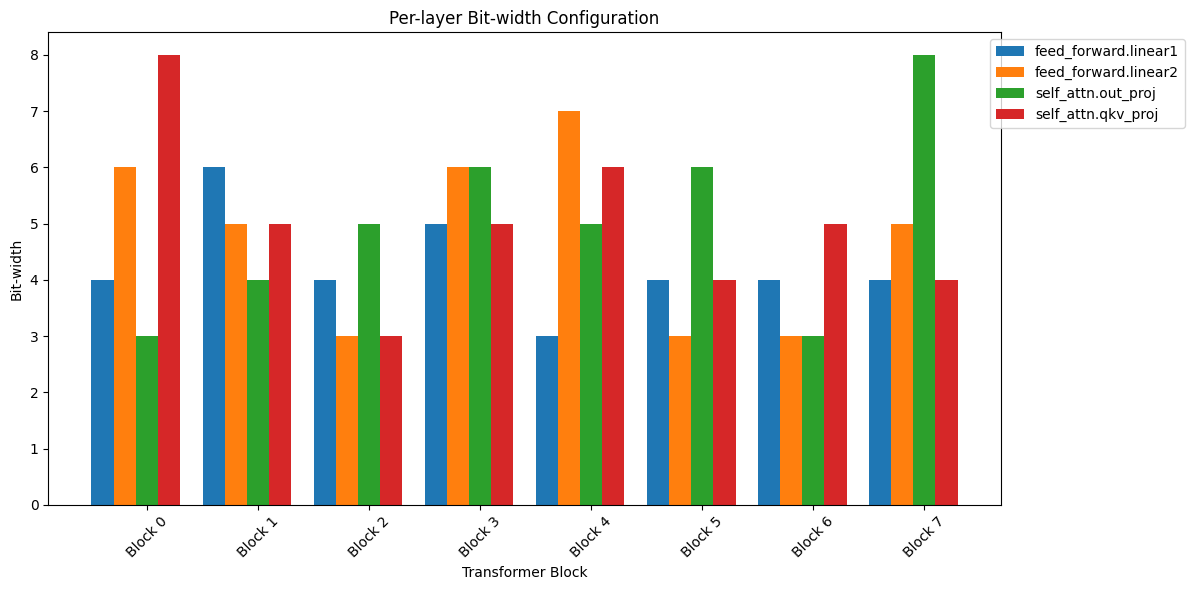

(<Figure size 1200x600 with 1 Axes>,
 <Axes: title={'center': 'Per-layer Bit-width Configuration'}, xlabel='Transformer Block', ylabel='Bit-width'>)

In [14]:
plot_bitwidth_config_per_layer(best_qconfig)

### Comparing to a Precomputed Search Result

To get a sense of what longer or more thorough searches might yield, we can also visualize a **previously optimized configuration**, obtained via:

- **2000 trials**
- A strong accuracy preference: $\alpha = 0.2$

This provides a useful baseline or reference for understanding how the search process evolves with more iterations and different objective weights.

Let’s load and plot that configuration:


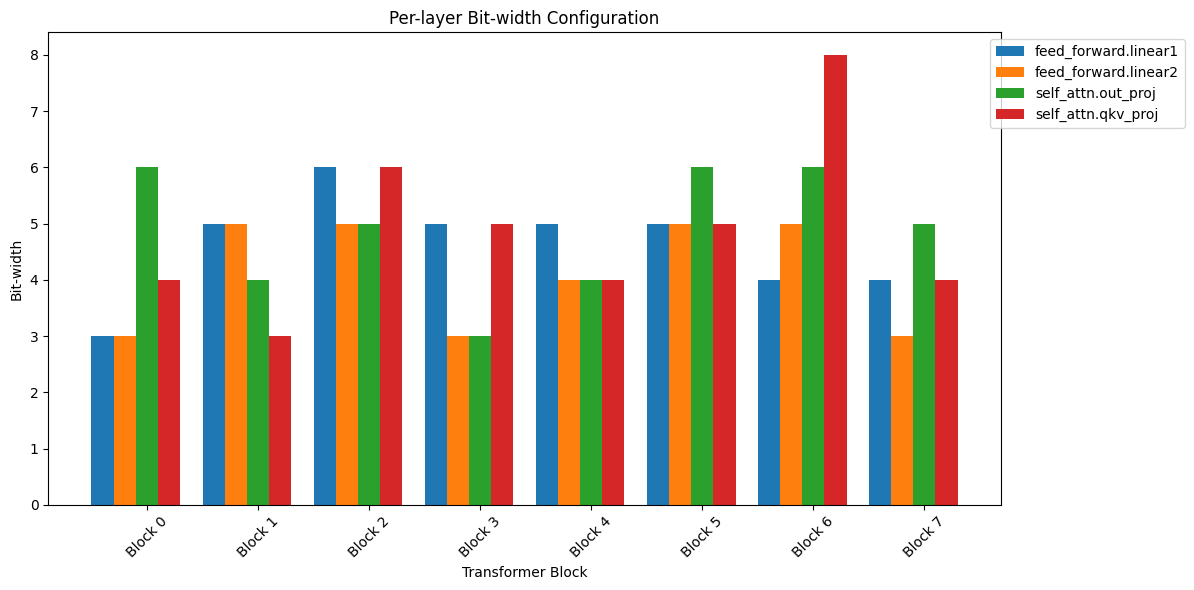

(<Figure size 1200x600 with 1 Axes>,
 <Axes: title={'center': 'Per-layer Bit-width Configuration'}, xlabel='Transformer Block', ylabel='Bit-width'>)

In [15]:
import pickle

with open('src/lab1/checkpoints/pretrained/best_qconfig.pkl', 'rb') as f:
    best_qconfig = pickle.load(f)

plot_bitwidth_config_per_layer(best_qconfig)


##  9. Precision vs. Accuracy Trade-off

To assess the benefits of **mixed-precision quantization** in the context of software-hardware co-design, we compare it against simpler **uniform-precision baselines**, where all layers share the same bit-width.

### Experimental Setup

We evaluate the model under a range of uniform bit-widths (from 8-bit to 2-bit) and record:

- **Validation loss**: accuracy after quantization  
- **Model size**: static memory footprint (in MB)

We then compare these baselines to the **mixed-precision configuration** found by the search algorithm.

This analysis addresses a key question:  
**Can adaptive bit-width allocation yield better accuracy at a comparable or lower memory cost?**

### Plotting the Trade-off

The plot below illustrates the trade-off between model size and validation loss:

- The **blue curve** traces uniform-precision results (each point labeled with its bit-width)  
- The **grey diamond** highlights the mixed-precision result

If the grey diamond appears **below and to the left** of the curve, it demonstrates that the mixed strategy achieves a **superior accuracy–efficiency balance** compared to any fixed-precision alternative.


In [18]:
import torch
import matplotlib.pyplot as plt
import numpy as np
import multiprocessing.util
multiprocessing.util._exit_function = lambda: None

def plot_precision_results(precisions=(8, 7, 6, 5, 4, 3),
                           mixed_qconfig=None,
                           batch_size=6,
                           checkpoint_path='src/lab1/checkpoints/pretrained/float-best-large.ckpt'):
    """
    Runs validation for mixed-precision settings, plots single-precision
    curve plus (optional) mixed-precision point, and returns fig, ax.
    """
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    results, sizes = [], []

    # Evaluate each uniform precision
    for prec in precisions:
        q = ShakespeareModule.load_from_checkpoint(checkpoint_path, batch_size=batch_size)
        q.setup('test')
        cfg = default_qconfig(q, bitwidth=prec)
        quantize_model(q, cfg).to(device)
        dl = q.test_dataloader()
        loss = compute_validation_loss(q, nn.CrossEntropyLoss(), dl, device)
        results.append(loss)
        sizes.append(compute_model_size_bytes(q, cfg) / (1024 ** 2))

    # Optionally evaluate one mixed-precision point
    mixed_point = None
    if mixed_qconfig is not None:
        q = ShakespeareModule.load_from_checkpoint(checkpoint_path, batch_size=batch_size)
        q.setup('test')
        quantize_model(q, mixed_qconfig).to(device)
        dl = q.test_dataloader()
        loss = compute_validation_loss(q, nn.CrossEntropyLoss(), dl, device)
        mem  = compute_model_size_bytes(q, mixed_qconfig) / (1024 ** 2)
        mixed_point = (mem, loss)

    # --- Start plotting ---
    plt.style.use('ggplot')
    fig, ax = plt.subplots(figsize=(8, 5))

    # Single-precision curve in default color C0
    ax.plot(sizes, results,
            marker='o',
            linestyle='-',
            linewidth=2,
            color='C0',
            label='Uniform Precision')

    # Annotate each point with its bitwidth
    for x, y, p in zip(sizes, results, precisions):
        ax.annotate(f"{p}-bit",
                    xy=(x, y),
                    xytext=(0, 8),
                    textcoords="offset points",
                    ha='center',
                    fontsize=10)

    # Mixed precision point in contrasting color C3
    if mixed_point:
        ax.scatter(*mixed_point,
                   s=120,
                   marker='D',
                   color='C3',
                   label='Mixed Precision',
                   zorder=5)
        ax.annotate("Mixed",
                    xy=mixed_point,
                    xytext=(10, -15),
                    textcoords="offset points",
                    fontsize=10,
                    arrowprops=dict(arrowstyle='->', lw=1, color='C3'))

    # A light dashed grid (major ticks only)
    ax.grid(True, which='major', axis='both', linestyle='--', alpha=0.6)

    # Axis labels, title, and ticks
    ax.set_xlabel('Model Size (MB)', fontsize=12)
    ax.set_ylabel('Validation Loss', fontsize=12)
    ax.set_title('Validation Loss vs. Quantization Precision', fontsize=14)
    ax.tick_params(axis='both', which='major', labelsize=11)

    # Tight legend in corner
    ax.legend(loc='upper right', frameon=False, fontsize=11)

    fig.tight_layout()
    return fig, ax


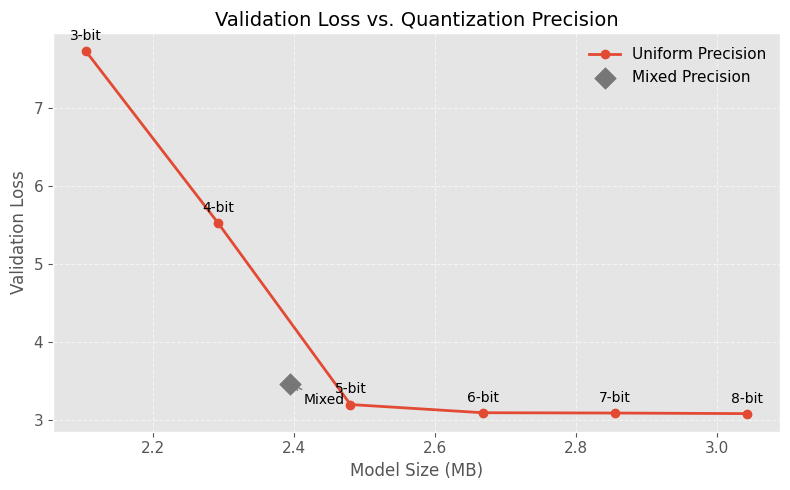

In [19]:
fig, ax = plot_precision_results(mixed_qconfig=best_qconfig)

You should see in the graph below, taht the Mixed-Precision quantization solution falls, below the uniform precision line plot. It hence, provides an improved memory-accuracy trade-of thanks to the help of software-hardware co-design. 

## Conclusion

In this lab, we explored **post-training quantization** as a hardware–software co-design tool for optimizing transformer models. By implementing an integer-only `QLinear` layer and automating per-layer bit-width assignment using `hyperopt`, we demonstrated how quantization directly impacts both **model size** and **predictive performance**.

Our experiments showed that selectively reducing bit-widths (e.g., to 2–4 bits) yields significant memory savings with modest accuracy trade-offs. The scalarized loss function allowed us to balance these trade-offs, adapting the quantization strategy to hardware constraints.

This lab highlights a key principle in efficient ML deployment: *quantization is not a post-hoc hack, but a tunable design dimension*. Co-designing quantization levels per layer, based on actual hardware cost and accuracy impact, enables principled, deployable models for edge and embedded applications.